# Task 1: Exploratory Data Analysis and Data Preprocessing

The objective of this task is to explore the CFPB complaint dataset, understand its structure and quality, and prepare complaint narratives for downstream Retrieval-Augmented Generation (RAG) development.

The preprocessing pipeline focuses on four target financial products:

- Credit Card
- Personal Loan
- Savings Account
- Money Transfer

The cleaned dataset produced in this task will serve as the foundation for text chunking, embedding generation, vector indexing, and chatbot development.

In [ ]:
import os
import sys
import seaborn as sns
sys.path.insert(0, '..')
from src.data_processor import load_dataset
import numpy as np
sns.set_theme(style='whitegrid')
%matplotlib inline


(9609797, 18)
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/processed/filtered_complaints.csv")

print(df.shape)

df.head()

(445456, 21)


,date_received,product,sub-product,issue,sub-issue,narrative,company_public_response,company,state,zip_code,...,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id,product_category,clean_narrative,word_count
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,...,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,Credit Card,a card was opened under my name by a fraudster...,82
1,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,...,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,Savings Account,i made the mistake of using my wellsfargo debi...,105
2,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,...,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,Credit Card,"dear cfpb, i have a secured credit card with c...",156
3,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,...,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,Credit Card,i have a citi rewards cards. the credit balanc...,229
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,...,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,Credit Card,b'i am writing to dispute the following charge...,469


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 445456 entries, 0 to 445455
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   date_received                 445456 non-null  str  
 1   product                       445456 non-null  str  
 2   sub-product                   426588 non-null  str  
 3   issue                         445456 non-null  str  
 4   sub-issue                     309985 non-null  str  
 5   narrative                     445456 non-null  str  
 6   company_public_response       179623 non-null  str  
 7   company                       445456 non-null  str  
 8   state                         440093 non-null  str  
 9   zip_code                      445456 non-null  str  
 10  tags                          78313 non-null   str  
 11  consumer_consent_provided?    445456 non-null  str  
 12  submitted_via                 445456 non-null  str  
 13  date_sent_to_company     

In [27]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date_received,445456,3736,2025-01-17,15841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,445456,6,Checking or savings account,140268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub-product,426588,27,General-purpose credit card or charge card,137167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue,445456,96,Managing an account,75691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub-issue,309985,100,Credit card company isn't resolving a dispute ...,27918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
narrative,445456,405220,I am filing a complaint against Cash App ( Blo...,7598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_public_response,179623,11,Company has responded to the consumer and the ...,154642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,445456,1843,"Block, Inc.",37659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,440093,62,CA,60746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,445456,6925,XXXXX,29447,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df.isnull().sum().sort_values(ascending=False)

consumer_disputed?              425127
tags                            367143
company_public_response         265833
sub-issue                       135471
sub-product                      18868
state                             5363
issue                                0
date_received                        0
product                              0
company                              0
zip_code                             0
consumer_consent_provided?           0
narrative                            0
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response?                     0
complaint_id                         0
product_category                     0
clean_narrative                      0
word_count                           0
dtype: int64

## Initial Observations

The processed dataset contains 445,456 complaint records after filtering and cleaning.

Each complaint includes:
- Product information
- Complaint narrative
- Cleaned narrative
- Product category
- Word count

The dataset is sufficiently large to support semantic search and RAG development.

In [82]:
product_counts = df["product_category"].value_counts()

product_counts

product_category
Credit Card        189295
Savings Account    140268
Money Transfer      98659
Personal Loan       17234
Name: count, dtype: int64

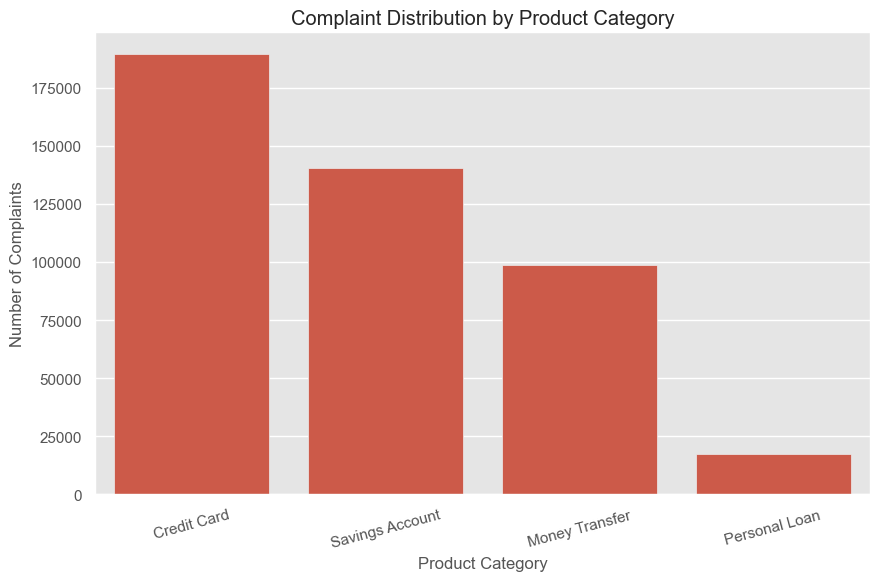

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_counts.index,
    y=product_counts.values
)

plt.title("Complaint Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=15)

plt.show()

In [84]:
(
    product_counts /
    product_counts.sum() * 100
).round(2)

product_category
Credit Card        42.49
Savings Account    31.49
Money Transfer     22.15
Personal Loan       3.87
Name: count, dtype: float64

### Product Distribution Findings

Credit Card complaints represent the largest category with approximately 189,295 complaints, accounting for roughly 42.5% of all filtered complaints.

Savings Account complaints account for approximately 31.5%, while Money Transfer complaints contribute around 22.1%.

Personal Loan complaints represent only 3.9% of the dataset, making them substantially underrepresented compared to the other financial products.

In [85]:
raw_df = pd.read_csv(
    "../data/raw/complaints.csv",
    engine="python",
    on_bad_lines="skip"
)

ArrowMemoryError: realloc of size 595591168 failed

In [ ]:
raw_df.columns = [
    c.strip().lower().replace(" ", "_")
    for c in raw_df.columns
]

In [ ]:
narrative_col = "consumer_complaint_narrative"

with_narrative = raw_df[narrative_col].notna().sum()

without_narrative = raw_df[narrative_col].isna().sum()

print(with_narrative)
print(without_narrative)

2980756
6629041


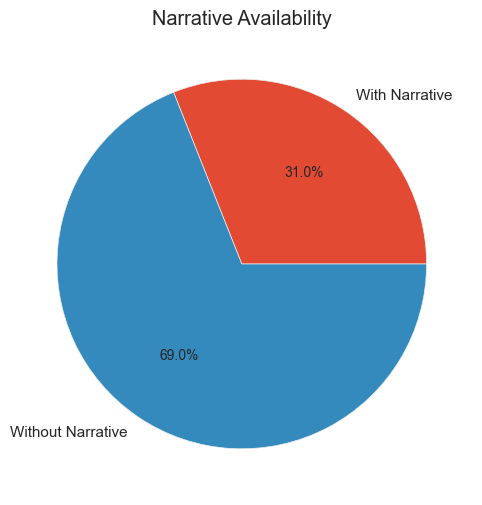

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    [with_narrative, without_narrative],
    labels=["With Narrative","Without Narrative"],
    autopct="%1.1f%%"
)

plt.title("Narrative Availability")

plt.show()

Section 6: Narrative Length Analysis

In [ ]:
df["word_count"].describe()

count    445456.000000
mean        197.869936
std         218.441168
min           1.000000
25%          79.000000
50%         131.000000
75%         245.000000
max        6263.000000
Name: word_count, dtype: float64

In [ ]:
df["word_count"].median()

np.float64(131.0)

In [ ]:
df["word_count"].mean()

np.float64(197.86993552674113)

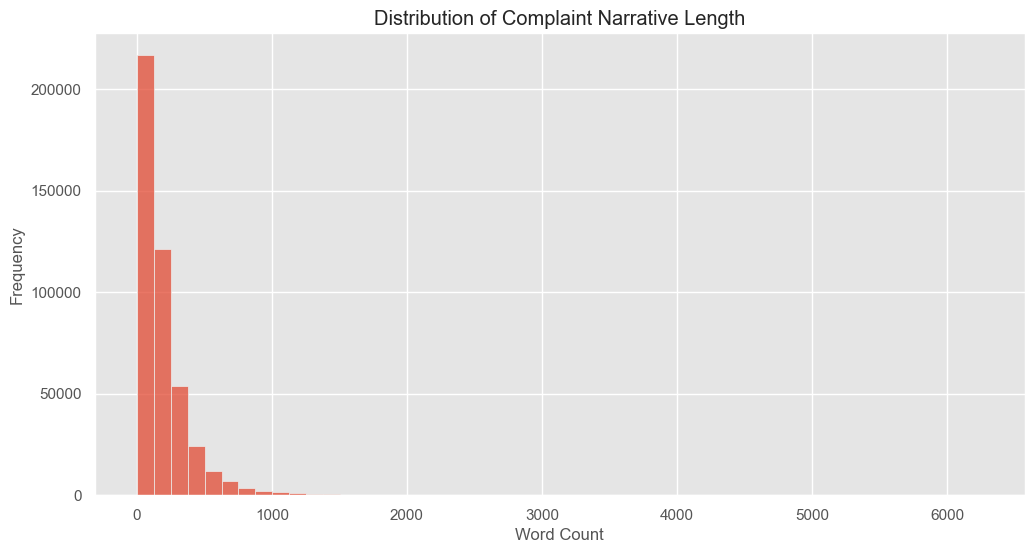

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Complaint Narrative Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

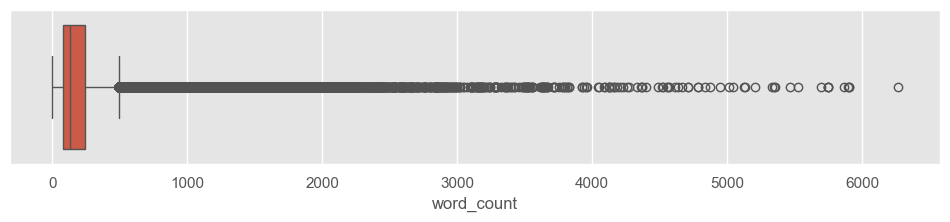

In [ ]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["word_count"]
)

plt.show()

Section 7: Narrative Length by Product

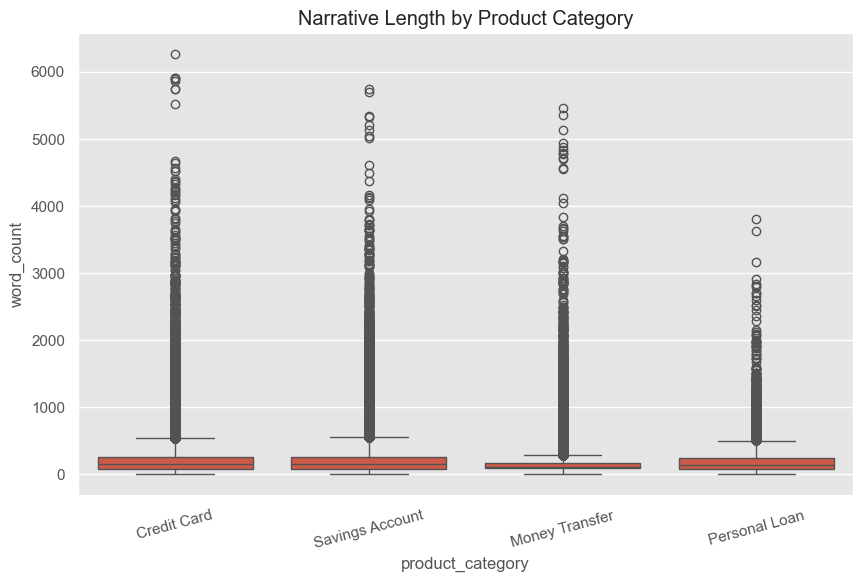

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="product_category",
    y="word_count"
)

plt.xticks(rotation=15)

plt.title(
    "Narrative Length by Product Category"
)

plt.show()

Section 8: Preprocessing Validation

In [ ]:
df[
    ["narrative","clean_narrative"]
].sample(5)

,narrative,clean_narrative
277117,Okay so on XX/XX/XXXX a friend asked me to con...,okay so on a friend asked me to convert on to ...
373486,Dispute Mishandling by Apple Card Team at Gold...,dispute mishandling by apple card team at gold...
332791,My identity and social security card was stole...,my identity and social security card was stole...
236397,On XX/XX/2022 I attempted to login to my Ulta ...,on 2022 i attempted to login to my ulta store ...
291936,"On XX/XX/XXXX, I purchased a round-trip airlin...","on , i purchased a round-trip airline ticket f..."


In [ ]:
print(df.shape)

(445456, 21)


## Key Findings

1. The original CFPB dataset contained over 9.6 million complaint records.

2. After filtering for the four target financial products and removing complaints without narratives, 445,456 complaints remained.

3. Credit Card complaints constitute the largest proportion of complaints, followed by Savings Accounts and Money Transfers.

4. Personal Loan complaints account for a relatively small share of the dataset.

5. Complaint narratives vary substantially in length, supporting the need for chunking before embedding generation.

6. Text normalization successfully removed noise and standardized complaint narratives for downstream semantic search.

In [48]:
df["word_count"].describe()

count    445456.000000
mean        197.869936
std         218.441168
min           1.000000
25%          79.000000
50%         131.000000
75%         245.000000
max        6263.000000
Name: word_count, dtype: float64

In [65]:
print("With narrative:", with_narrative)
print("Without narrative:", without_narrative)

With narrative: 2980756
Without narrative: 6629041


In [72]:
df.sort_values("word_count").head(10)[
    ["clean_narrative", "word_count"]
]

,clean_narrative,word_count
349124,itriedfilingadisputewithcapitaloneonlineonafew...,1
232336,capitaloneallowedadatabreachthatxxxxhavedistri...,1
248718,receivede-mailthatcreditcardhadbeenclosedaweek...,1
209473,fridayidepositedacheckandwastoldineededtopayaf...,1
250785,afterseveralincidenceswithcapitalonethatseemed...,2
432714,unauthorized wiyhdrawal,2
383378,unrecognizable charge,2
272389,ihaveacreditcardwithcitibank.mybalancewasxxxxu...,2
445124,unauthorized transaction,2
364645,thiscompanyisfinancinghurtingme.ineededmoneyan...,2


In [64]:
df[["narrative","clean_narrative"]].sample(2)

,narrative,clean_narrative
63301,I deposited XXXX checks ( {$1000.00} each ) to...,i deposited checks ( 1000.00 each ) to my acco...
51391,Capital 1says there's a problem with there ser...,capital 1says there's a problem with there ser...


In [69]:
df.sort_values("word_count").head(10)[
    ["clean_narrative", "word_count"]
]

,clean_narrative,word_count
349124,itriedfilingadisputewithcapitaloneonlineonafew...,1
232336,capitaloneallowedadatabreachthatxxxxhavedistri...,1
248718,receivede-mailthatcreditcardhadbeenclosedaweek...,1
209473,fridayidepositedacheckandwastoldineededtopayaf...,1
250785,afterseveralincidenceswithcapitalonethatseemed...,2
432714,unauthorized wiyhdrawal,2
383378,unrecognizable charge,2
272389,ihaveacreditcardwithcitibank.mybalancewasxxxxu...,2
445124,unauthorized transaction,2
364645,thiscompanyisfinancinghurtingme.ineededmoneyan...,2


In [31]:
df["product_category"].value_counts()

product_category
Credit Card        189295
Savings Account    140268
Money Transfer      98659
Personal Loan       17234
Name: count, dtype: int64